-Machine Learning :

- Assignment 1: Data Preprocessing.

Name:Aseel Anwar AbuAlatta.

Student number:2320221991.


في هذا القسم سنقوم بتحميل البيانات وفحصها وتحسين استهلاك الذاكرة

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


في هذا القسم سنقوم بتحميل البيانات وفحصها وتحسين استهلاك الذاكرة

In [ ]:
# ====================== تحميل البيانات ======================
# طريقة 1: رفع الملفات يدوياً (موصى بها)
# أو طريقة 2: تحميل مباشرة من Kaggle (لو عندك API)
print("رفع ملفات train.csv و test.csv")
from google.colab import files
uploaded = files.upload()
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()


رفع ملفات train.csv و test.csv


Saving test.csv to test (2).csv
Saving train.csv to train (1).csv
Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


قمنا بتحويل أنواع البيانات لتقليل استهلاك الذاكرة

In [ ]:
# Memory Optimization
def optimize_dtypes(df):
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    return df
train = optimize_dtypes(train)
test = optimize_dtypes(test)
# Missing Values Analysis
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("أعمدة فيها قيم مفقودة:\n", missing)
# Features where NaN means "No" (مثل No Pool)
no_features = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
               'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
               'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for col in no_features:
    if col in train.columns:
        train[col] = train[col].fillna('None')
        if col in test.columns:
            test[col] = test[col].fillna('None')
# Fill numerical missing with median
num_cols = train.select_dtypes(include=['number']).columns
for col in num_cols:
    if train[col].isnull().sum() > 0:
        median = train[col].median()
        train[col] = train[col].fillna(median)
        if col in test.columns:
            test[col] = test[col].fillna(median)
print("تم معالجة القيم المفقودة")


أعمدة فيها قيم مفقودة:
 PoolQC          1452
MiscFeature     1404
Alley           1367
Fence           1177
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64
تم معالجة القيم المفقودة


لاحظنا أن بعض الأعمدة تحتوي على نسبة عالية من القيم المفقودة

لكن أعمدة مثل **PoolQC, Alley, Fence, MiscFeature** تعني "لا يوجد" وليست missing.


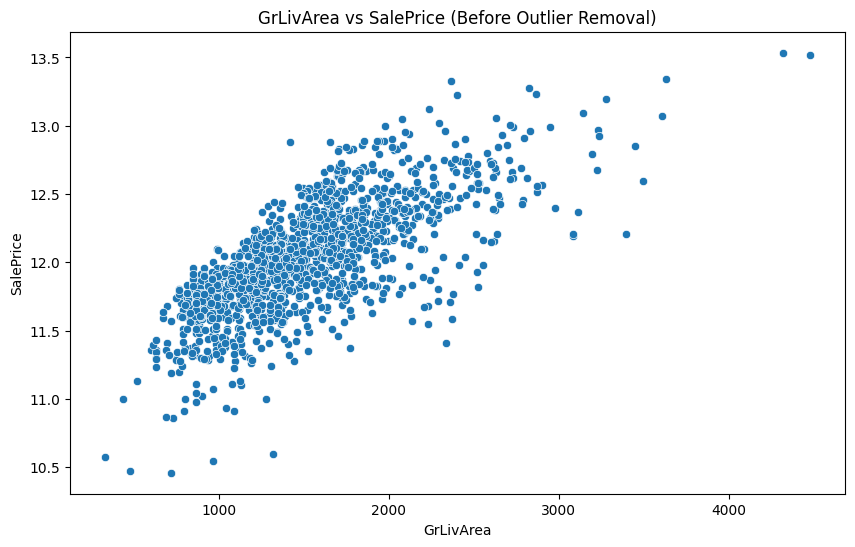

تم تحويل SalePrice باستخدام Log


In [ ]:
# Outlier Detection (GrLivArea)
plt.figure(figsize=(10,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'])
plt.title('GrLivArea vs SalePrice (Before Outlier Removal)')
plt.show()
# إزالة Outliers كبيرة جداً
train = train[train['GrLivArea'] < 4500]
# Log Transformation لـ SalePrice (مهم جداً)
train['SalePrice'] = np.log1p(train['SalePrice'])
print("تم تحويل SalePrice باستخدام Log")

سنقوم بدراسة الارتباط بين المتغيرات وإنشاء بعض الرسوم البيانية المهمة

Top 5 Features correlated with SalePrice:
 SalePrice      1.000000
OverallQual    0.819157
GrLivArea      0.721002
GarageCars     0.680545
GarageArea     0.654767
TotalBsmtSF    0.644218
Name: SalePrice, dtype: float64


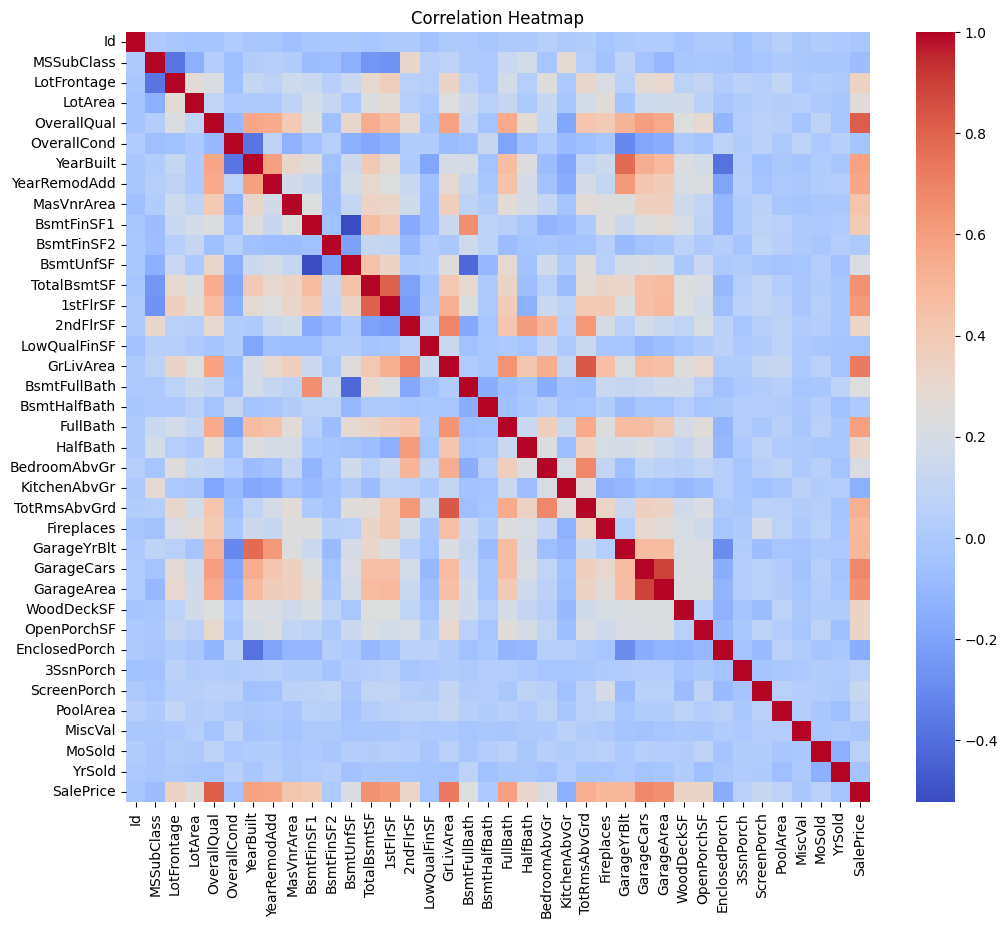

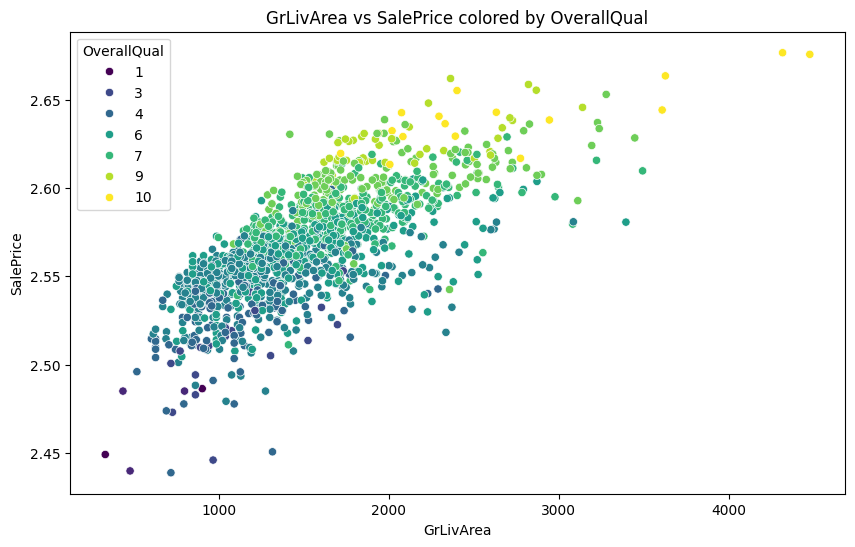

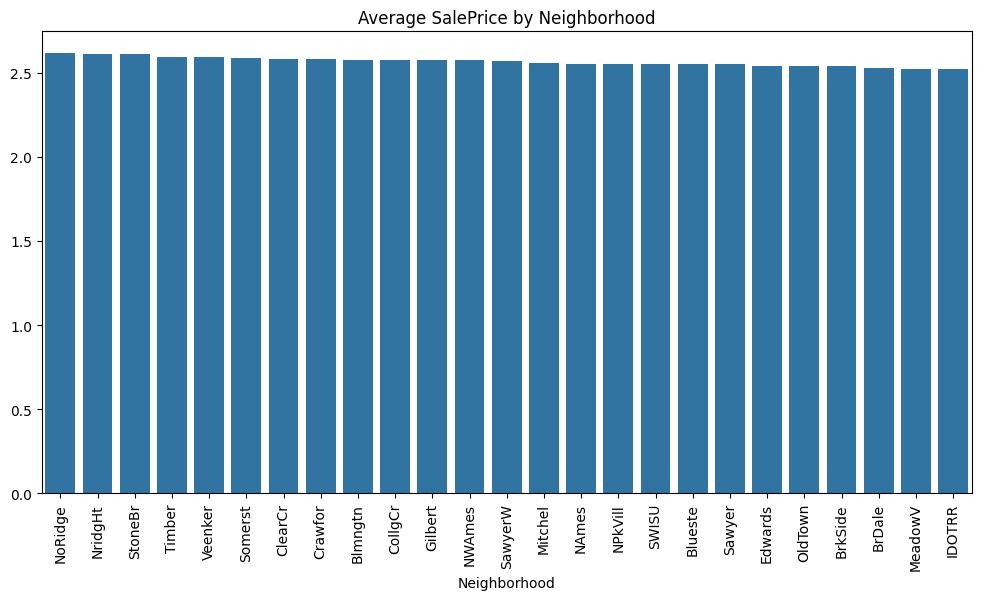

In [ ]:
# Correlation
num_features = train.select_dtypes(include=['number']).columns
corr = train[num_features].corr()
top_corr = corr['SalePrice'].sort_values(ascending=False).head(6)
print("Top 5 Features correlated with SalePrice:\n", top_corr)
# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')
plt.show()
# Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x=train['GrLivArea'], y=train['SalePrice'], hue=train['OverallQual'], palette='viridis')
plt.title('GrLivArea vs SalePrice colored by OverallQual')
plt.show()
# Neighborhood Analysis
plt.figure(figsize=(12,6))
neigh_price = train.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
sns.barplot(x=neigh_price.index, y=neigh_price.values)
plt.xticks(rotation=90)
plt.title('Average SalePrice by Neighborhood')
plt.show()


In [ ]:

# Total Square Feet
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']
test['TotalSF'] = test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF']
# Label Encoding for Ordinal Features
ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
label_encoders = {}
for col in ordinal_cols:
    if col in train.columns:
        le = LabelEncoder()
        train[col] = le.fit_transform(train[col])
        if col in test.columns:
            test[col] = le.transform(test[col].fillna('None'))
        label_encoders[col] = le
# One-Hot Encoding for Nominal Features
nominal_cols = ['MSZoning', 'Street', 'Neighborhood', 'BldgType', 'HouseStyle',
                'RoofStyle', 'Foundation', 'SaleType', 'SaleCondition']
train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)
test = pd.get_dummies(test, columns=nominal_cols, drop_first=True)
# Align columns
test = test.reindex(columns=train.columns, fill_value=0)
print("تم Feature Engineering بنجاح")
print(f"Final shape: {train.shape}")


ValueError: invalid literal for int() with base 10: 'TA'

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
        return X
print("Pipeline جاهزة للاستخدام")


Pipeline جاهزة للاستخدام
